# Action potential waveforms are state-dependent
### 4. Within-neuron waveform variability can exceed between-neuron differences

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

Spike sorting, the standard way of assigning extracellularly recorded spikes to individual neurons, rests on the assumption that each neuron fires a consistent spike shape that is distinct from its neighbors'. Finding 3 showed that single neurons can switch between distinct spike shapes. Here we ask how big that variability is: how different can two spikes from the same neuron be, compared with spikes from two different neurons?

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys

sys.path.append('finding_notebooks_functions/')
from finding4_functions import (load_distance_data, print_within_between_summary, plot_fig4d,
                                plot_within_vs_between_groups, cell_comparison_explorer)

# all data used here ships with the repo (see finding_notebooks_data/build_finding4_data.py)
DATA_DIR = 'finding_notebooks_data/finding4/'
data = load_distance_data(DATA_DIR)

## Measuring how different two spike shapes are

We use the same spe-1 recordings as Finding 3: intracellular spikes from 43 neurons in rat motor and somatosensory cortex, firing spontaneously (see notebook 5 for the full dataset description).

To compare spike shapes we use the **normalized root mean squared error (nRMSE)**: the point by point difference between two waveforms (the shaded area in the Fig. 4D schematic), scaled by the spike's peak amplitude so that cells with larger spikes are not automatically "more different". An nRMSE of 0 means identical waveforms.

<img src="finding_notebooks_data/paper_figures/fig4_D.png" width="650">

We computed it two ways:
- **within a cell**: each single spike against its own cell's average spike;
- **between cells**: each single spike against the average spike of every other cell.

We also report **cosine similarity**, which compares shape alone, ignoring amplitude (1 means the same shape).

## Most of the time, spikes look more like their own neuron

As expected for spike sorting to work, a spike is usually much closer to its own cell's average than to another cell's: within-cell nRMSE was substantially lower than between-cell nRMSE, and the same was true for cosine similarity.

But this is not true for every cell. In 2 neurons, the typical (median) spike was further from its own cell's average than the typical spike was from another cell's average, and in 4 neurons more than a quarter of spikes crossed that line.

In [2]:
print_within_between_summary(data)

nRMSE, median:              within cell 0.076   between cells 0.257
cosine similarity, median:  within cell 0.984   between cells 0.762

Cells whose median single spike nRMSE exceeds the between-cell median: c27 (97.6% of spikes above), c5 (66.5% of spikes above)
Cells with more than 25% of spikes above the between-cell median: 4
Cells with more than 10% of spikes above the between-cell median: 8


Below: every cell, sorted from least to most variable (Fig. 4D). Each dot is one spike's nRMSE to its own cell's average (up to 300 spikes shown per cell) and the black diamond is the cell's median. The grey band and dashed line are the interquartile range and median of the between-cell nRMSE. Orange and red dots are spikes that fall within or above the range of differences between two different neurons.

[sorted_dots] cache HIT


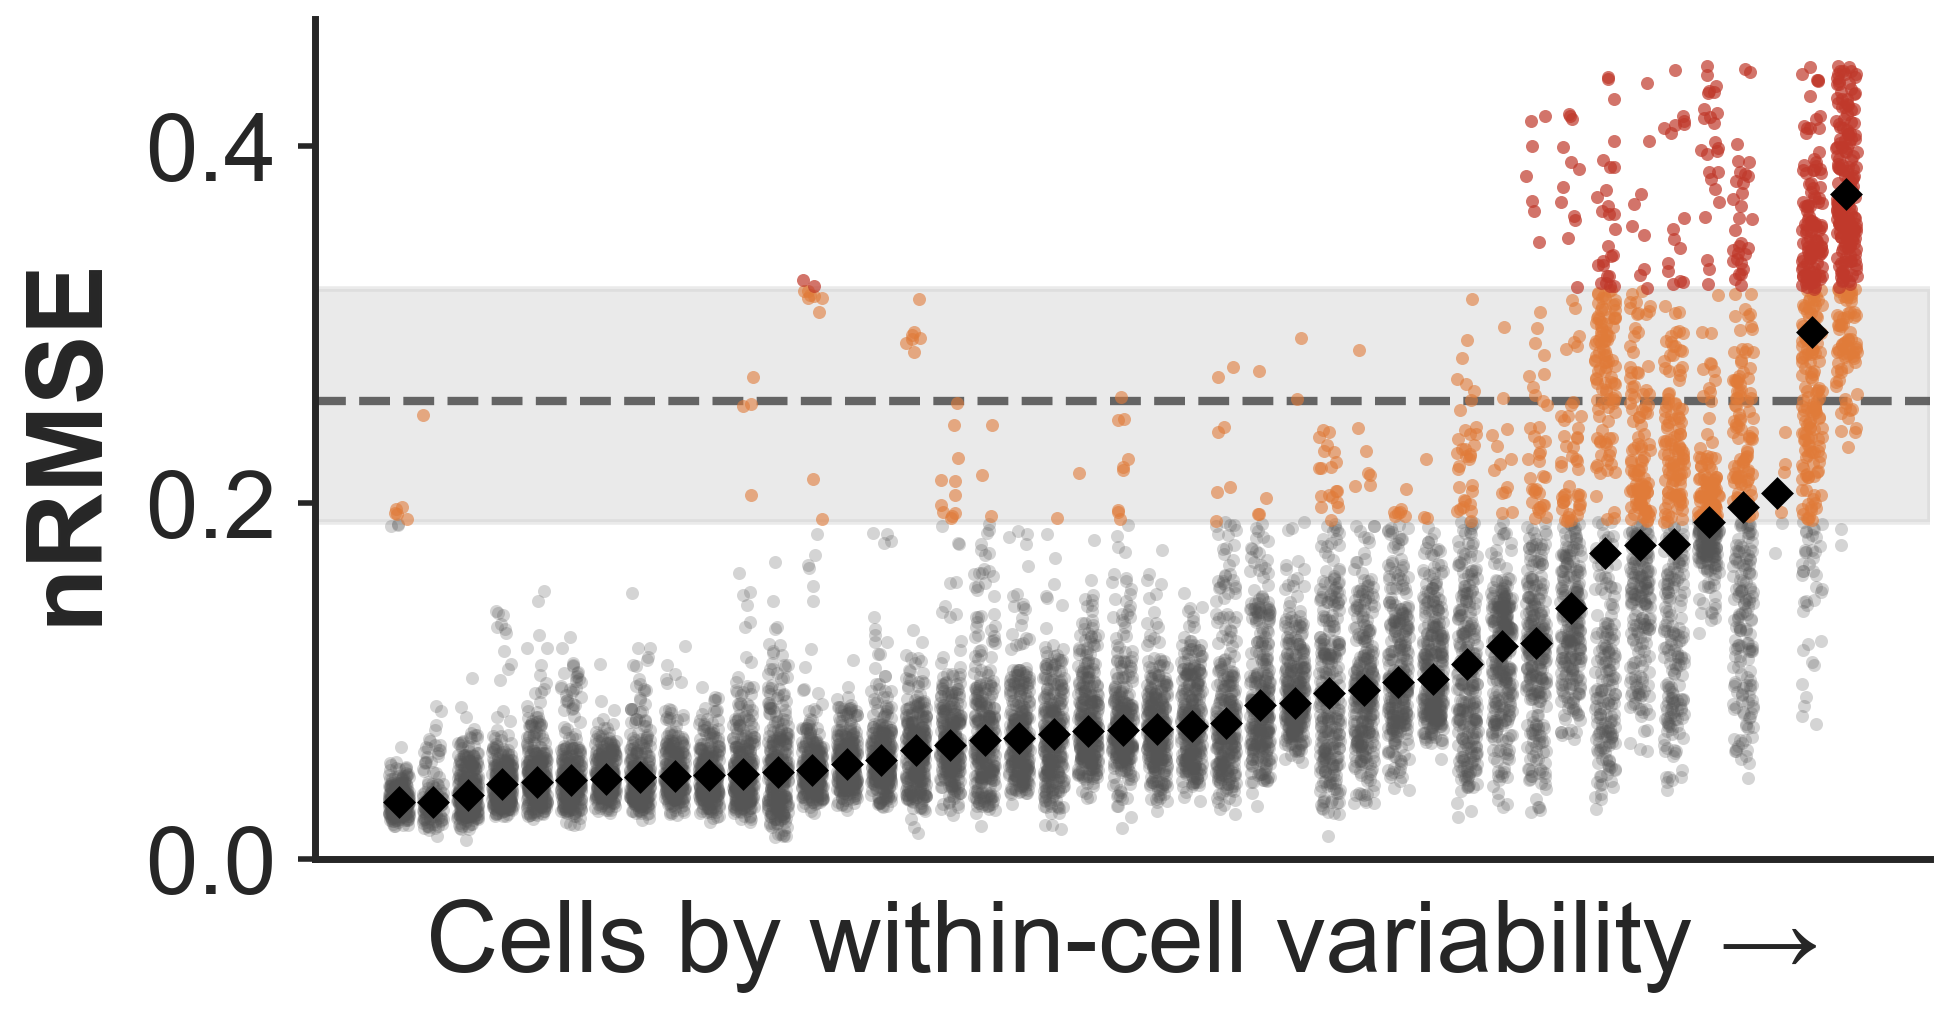

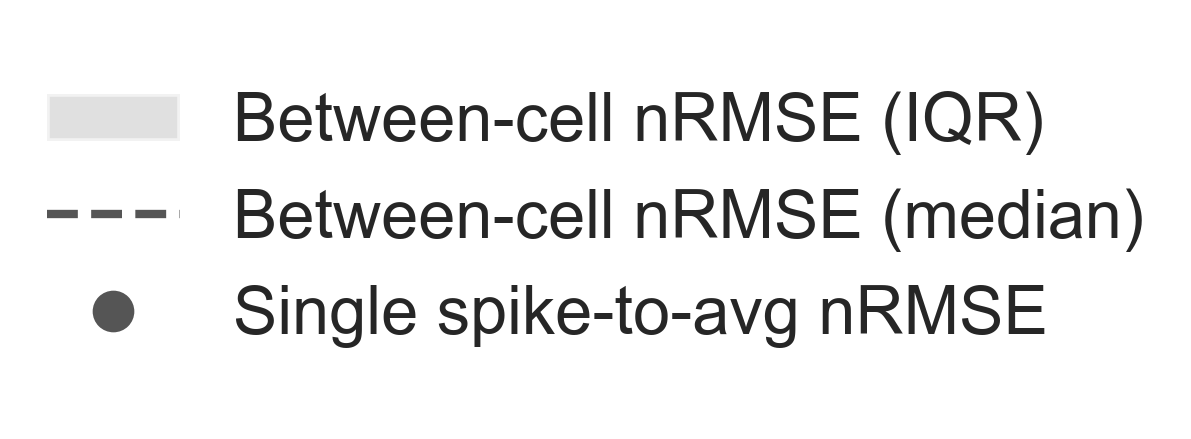

In [3]:
plot_fig4d(data)

## The same holds within cell types and recording methods

Different neurons might look alike simply because they are the same type of cell, or because they were recorded the same way. Restricting the between-cell comparison to cells of the same putative type (pyramidal with pyramidal, interneuron with interneuron) or the same recording method (juxtacellular or whole-cell) gave the same pattern (Supp. Fig. 14B).

[spike_to_avg] cache HIT — loading


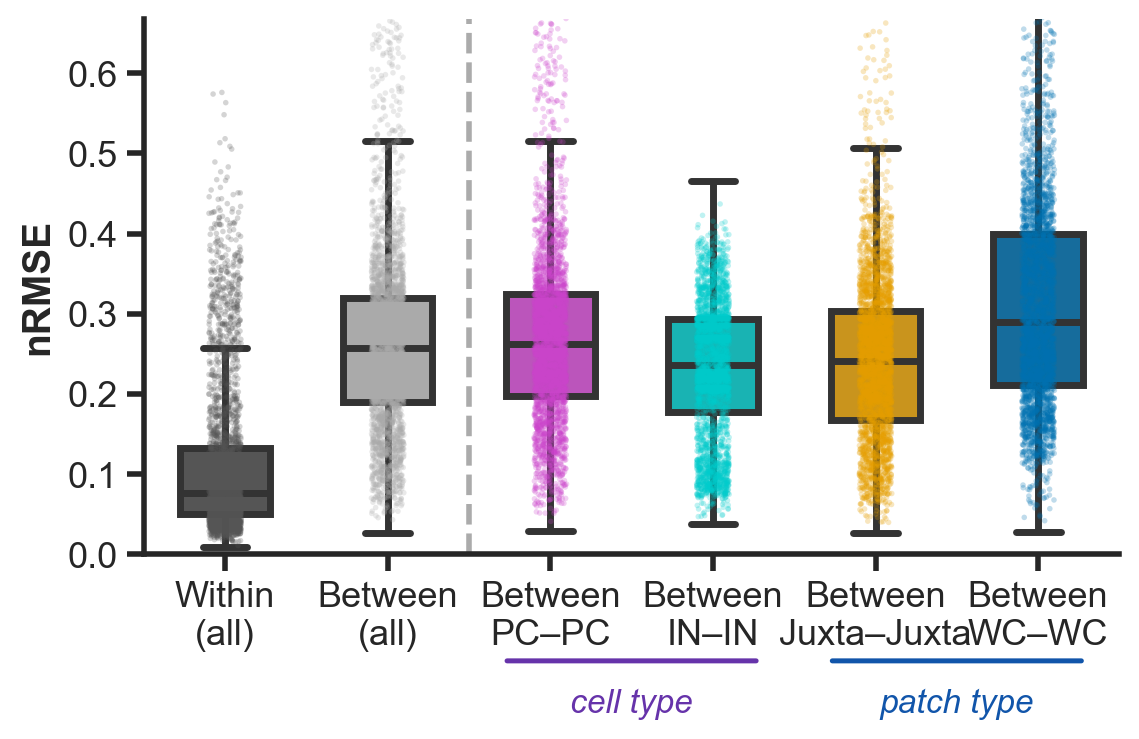


── nRMSE (spike-to-avg) ──
  Within (all)          : median=0.076  IQR=[0.050, 0.133]  n=167006
  Between (all)         : median=0.257  IQR=[0.189, 0.320]  n=200000
  Between PC–PC         : median=0.263  IQR=[0.197, 0.324]  n=200000
  Between IN–IN         : median=0.236  IQR=[0.178, 0.294]  n=200000
  Between Juxta–Juxta   : median=0.241  IQR=[0.167, 0.303]  n=200000
  Between WC–WC         : median=0.290  IQR=[0.211, 0.399]  n=77752


In [4]:
plot_within_vs_between_groups(data)

## Which features vary the most?

Repeating the comparison on individual `spikewise` features, rather than the whole waveform, showed that the overlap depends on the feature (Supp. Fig. 14C, D). Ramp amplitude and inflection amplitude overlapped the most between cells: the typical within-cell difference was 49% and 62% of the typical between-cell difference. Peak amplitude and peak sharpness separated neurons most clearly (8% and 9%).

Individual spikes crossed the between-cell level far more often for single features than for the whole waveform. For the whole waveform, 8 cells had more than 10% of their spikes above the between-cell median. For single features, ramp amplitude and inflection amplitude did so in 32 cells each and the decay rate in 19, while peak amplitude and peak sharpness stayed near zero in every cell.

Together, these results show that spikes from the same neuron can sometimes look as different as, or more different than, spikes from different neurons. For spike sorting, this means a neuron whose spike shape changes with its state could be split into two units, each carrying part of its spike train.

(These feature-level panels need every raw spike fit, which is too large to ship with the repo; see `AP_empirical_paper_all_analyses/paper_aux_figs/spe1/supp_within_vs_between_waveform.ipynb`.)

## Explore a cell

Pick a cell, and a second cell to compare it with:
1. **left**: single spikes from the first cell (grey) against its own average (green), with one typical spike highlighted and its difference from the average shaded;
2. **middle**: the two cells' average spikes, and the nRMSE between them;
3. **right**: how far every spike of the first cell is from its own average (green), and how far a random sample of its spikes is from the second cell's average (outline), against the range of differences between any two cells (grey).

The cells with the most within-cell variability are c27, c5, c21 and c3.

(Static snapshot. Run this cell to use the interactive controls.)


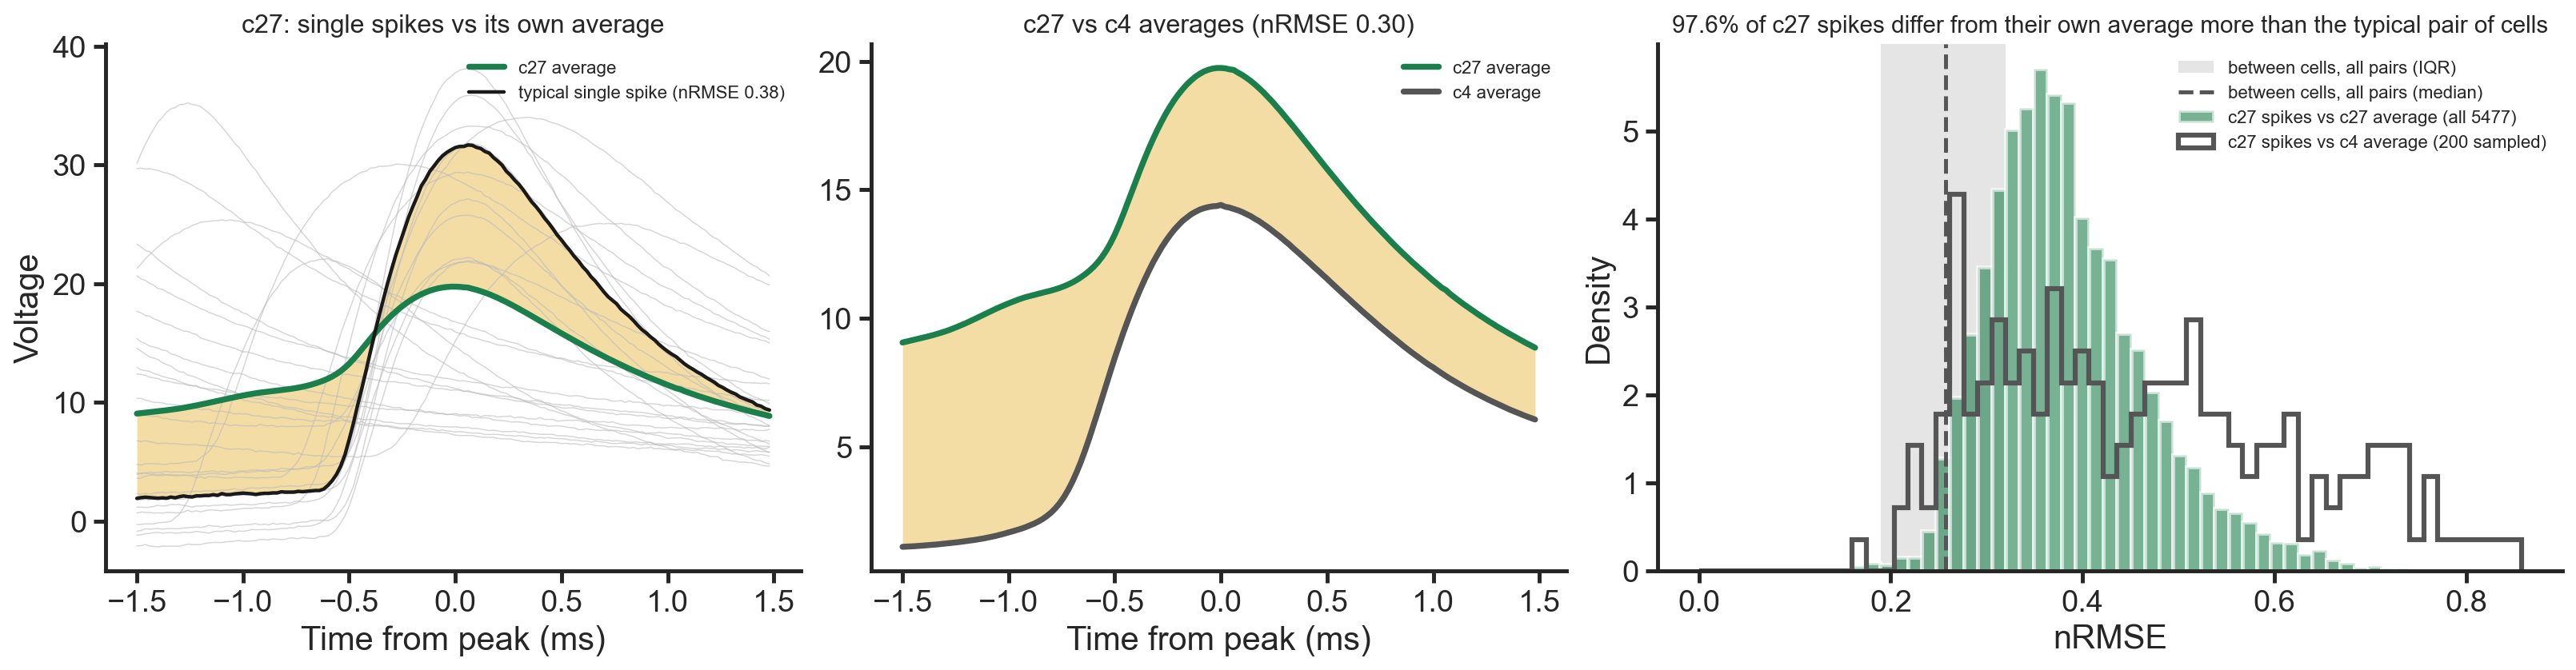

In [5]:
cell_comparison_explorer(data, cell='c27', other='c4')